# WESAD — Explainable Boosting Machine (EBM)

**Protocol:**
- S2 is held out as the final test subject — never seen during development
- LOSO cross-validation over the remaining 14 subjects estimates generalisation
- Final EBM is trained on all 14 dev subjects, evaluated once on S2

In [2]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

PROCESSED_DIR = Path("../data/WESAD/processed_engineered_dropnan")

X      = np.load(PROCESSED_DIR / "X.npy")
y      = np.load(PROCESSED_DIR / "y.npy")
groups = np.load(PROCESSED_DIR / "groups.npy")

with open(PROCESSED_DIR / "feature_cols.json") as f:
    FEATURE_COLS = json.load(f)

assert X.shape[1] == len(FEATURE_COLS), \
    f"Shape mismatch: {X.shape[1]} cols vs {len(FEATURE_COLS)} names"

print(f"X      : {X.shape}")
print(f"y      : {y.shape}  —  stress={y.sum()}, non-stress={(y==0).sum()}")
print(f"Groups : {sorted(np.unique(groups).tolist())}")
print(f"Features: {len(FEATURE_COLS)}")

X      : (121808, 119)
y      : (121808,)  —  stress=36264, non-stress=85544
Groups : [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
Features: 119


### Train / test split

S2 is locked away as the test subject. Everything below this point only touches `X_dev` / `y_dev` until the final evaluation cell.

In [3]:
TEST_SUBJECT = 2   # S2 — held out until final evaluation

test_mask = groups == TEST_SUBJECT
dev_mask  = ~test_mask

X_dev,  y_dev,  groups_dev  = X[dev_mask],  y[dev_mask],  groups[dev_mask]
X_test, y_test, groups_test = X[test_mask], y[test_mask], groups[test_mask]

total = len(y)
print(f"Dev  : {X_dev.shape[0]:>6} windows  ({X_dev.shape[0]/total*100:.1f}%)  across {np.unique(groups_dev).tolist()}")
print(f"Test : {X_test.shape[0]:>6} windows  ({X_test.shape[0]/total*100:.1f}%)  (S{TEST_SUBJECT} only)")
print(f"Split: {X_dev.shape[0]/total*100:.1f}% dev / {X_test.shape[0]/total*100:.1f}% test")
print()
print(f"Dev  stress rate : {y_dev.mean()*100:.1f}%")
print(f"Test stress rate : {y_test.mean()*100:.1f}%")

Dev  : 114044 windows  (93.6%)  across [3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17]
Test :   7764 windows  (6.4%)  (S2 only)
Split: 93.6% dev / 6.4% test

Dev  stress rate : 29.9%
Test stress rate : 28.6%


### LOSO cross-validation (development set)

Leave-one-subject-out over the 14 dev subjects. Each fold trains on 13 subjects and validates on the held-out one — simulating deployment on a new person.

In [28]:
logo        = LeaveOneGroupOut()
dev_results = []

for fold, (train_idx, val_idx) in enumerate(logo.split(X_dev, y_dev, groups_dev)):
    X_train, X_val = X_dev[train_idx], X_dev[val_idx]
    y_train, y_val = y_dev[train_idx], y_dev[val_idx]

    ebm = ExplainableBoostingClassifier(
        feature_names=FEATURE_COLS,
        max_bins=128,
        max_interaction_bins=32,
        interactions=0,
        learning_rate=0.01,
        min_samples_leaf=2,
        random_state=42,
    )
    ebm.fit(X_train, y_train)

    preds             = ebm.predict(X_val)
    held_out_subject  = groups_dev[val_idx][0]
    f1                = f1_score(y_val, preds, average="macro")
    acc               = accuracy_score(y_val, preds)

    dev_results.append({"subject": held_out_subject, "f1": f1, "accuracy": acc})
    print(f"S{held_out_subject:2d}  F1={f1:.3f}  Acc={acc:.3f}")

dev_df = pd.DataFrame(dev_results)
print(f"\nMean dev F1       : {dev_df['f1'].mean():.3f}  ±  {dev_df['f1'].std():.3f}")
print(f"Mean dev Accuracy : {dev_df['accuracy'].mean():.3f}  ±  {dev_df['accuracy'].std():.3f}")

/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


S 3  F1=0.878  Acc=0.909


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


S 4  F1=0.717  Acc=0.819


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


...

S15  F1=0.915  Acc=0.933


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


S16  F1=1.000  Acc=1.000


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


S17  F1=0.837  Acc=0.844

Mean dev F1       : 0.855  ±  0.139
Mean dev Accuracy : 0.892  ±  0.087


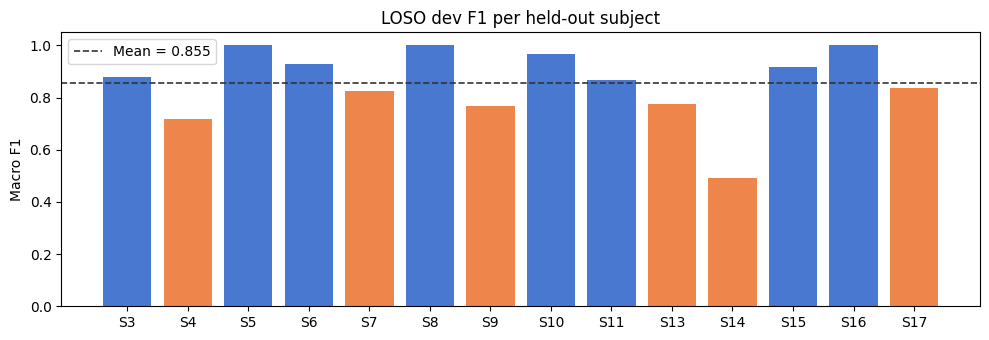

In [29]:
# Per-subject F1 bar chart
fig, ax = plt.subplots(figsize=(10, 3.5))
colors = ["#ee854a" if f < dev_df["f1"].mean() else "#4878d0" for f in dev_df["f1"]]
ax.bar([f"S{s}" for s in dev_df["subject"]], dev_df["f1"], color=colors)
ax.axhline(dev_df["f1"].mean(), color="#333", lw=1.2, ls="--", label=f"Mean = {dev_df['f1'].mean():.3f}")
ax.set_ylabel("Macro F1")
ax.set_title("LOSO dev F1 per held-out subject")
ax.legend()
plt.tight_layout()
plt.show()

### Ablation experiments

Compare how feature engineering choices and sensor coverage affect LOSO F1. Six conditions, each using the same EBM hyperparameters as the main LOSO cell. Run cells one at a time to see results as they come in.

In [ ]:
# ── Feature subsets ───────────────────────────────────────────────────────
SIMPLE_SUFFIXES = ('_mean', '_median', '_std')

subsets = {
    "simple":     [f for f in FEATURE_COLS if any(f.endswith(s) for s in SIMPLE_SUFFIXES)],
    "engineered": [f for f in FEATURE_COLS if not any(f.endswith(s) for s in SIMPLE_SUFFIXES)],
    "wrist_only": [f for f in FEATURE_COLS if f.startswith(('wrist_', 'bvp_'))],
    "chest_only": [f for f in FEATURE_COLS if f.startswith(('ecg_', 'chest_', 'emg_', 'resp_', 'cross_'))],
    "no_acc":     [f for f in FEATURE_COLS if '_ACC_' not in f],
}
for name, feats in subsets.items():
    print(f"{name:>12}: {len(feats)} features")


# ── Per-subject baseline normalisation ────────────────────────────────────
def normalize_to_baseline(X, y, groups):
    """Z-score each subject using their own non-stress (y=0) windows as reference."""
    X_norm = X.copy().astype(np.float64)
    for sid in np.unique(groups):
        mask      = groups == sid
        base_mask = mask & (y == 0)
        mu  = np.nanmean(X[base_mask], axis=0)
        sig = np.nanstd(X[base_mask],  axis=0)
        sig[sig < 1e-8] = 1.0          # avoid div-by-zero for constant features
        X_norm[mask] = (X[mask] - mu) / sig
    return X_norm


# ── LOSO helper ───────────────────────────────────────────────────────────
def run_loso(Xd, Xt, yd, yt, gd, feat_names, label):
    results = []
    header  = f"{'Fold':>4}  {'Subj':>5}  {'F1':>6}  {'Acc':>6}  {'RunMean':>8}  {'RunStd':>7}"
    print(f"\n{'═'*52}\n  {label}  ({len(feat_names)} features)\n{'═'*52}")
    print(header); print("─"*52)

    for fold, (tr, va) in enumerate(LeaveOneGroupOut().split(Xd, yd, gd), 1):
        ebm = ExplainableBoostingClassifier(
            feature_names=feat_names, max_bins=128, max_interaction_bins=32,
            interactions=0, learning_rate=0.01, min_samples_leaf=2, random_state=42,
        )
        ebm.fit(Xd[tr], yd[tr])
        preds = ebm.predict(Xd[va])
        subj  = gd[va][0]
        f1    = f1_score(yd[va], preds, average="macro")
        acc   = accuracy_score(yd[va], preds)
        results.append({"subject": subj, "f1": f1, "accuracy": acc})
        run_f1s = [r["f1"] for r in results]
        print(f"{fold:>4}  S{subj:>4}  {f1:>6.3f}  {acc:>6.3f}  "
              f"{np.mean(run_f1s):>8.3f}  {np.std(run_f1s):>7.3f}")

    df = pd.DataFrame(results)
    print("─"*52)
    print(f"  LOSO F1  : {df['f1'].mean():.3f} ± {df['f1'].std():.3f}")
    print(f"  LOSO Acc : {df['accuracy'].mean():.3f} ± {df['accuracy'].std():.3f}")

    return df

      simple: 32 features
  engineered: 87 features
  wrist_only: 47 features
  chest_only: 72 features
      no_acc: 89 features


In [21]:
# ── Ablation 1: simple features only ──────────────────────────────────────
abl_results = {}
idx = [FEATURE_COLS.index(f) for f in subsets["simple"]]
abl_results["simple"] = run_loso(
    X_dev[:, idx], X_test[:, idx], y_dev, y_test, groups_dev, subsets["simple"], "simple"
)


════════════════════════════════════════════════════
  simple  (32 features)
════════════════════════════════════════════════════
Fold   Subj      F1     Acc   RunMean   RunStd
────────────────────────────────────────────────────
   1  S   3   0.920   0.938     0.920    0.000
   2  S   4   0.709   0.816     0.815    0.106
   3  S   5   0.595   0.768     0.741    0.135
   4  S   6   0.983   0.986     0.802    0.157
   5  S   7   0.607   0.607     0.763    0.161
   6  S   8   1.000   1.000     0.802    0.171
   7  S   9   0.990   0.992     0.829    0.172
   8  S  10   1.000   1.000     0.851    0.170
   9  S  11   0.941   0.948     0.861    0.163
  10  S  13   0.801   0.811     0.855    0.156
  11  S  14   0.574   0.752     0.829    0.169
  12  S  15   0.893   0.911     0.834    0.163
  13  S  16   0.908   0.928     0.840    0.157
  14  S  17   0.688   0.772     0.829    0.157
────────────────────────────────────────────────────
  LOSO F1  : 0.829 ± 0.163
  LOSO Acc : 0.874 ± 0.120


In [22]:
# ── Ablation 2: engineered features only ──────────────────────────────────
idx = [FEATURE_COLS.index(f) for f in subsets["engineered"]]
abl_results["engineered"] = run_loso(
    X_dev[:, idx], X_test[:, idx], y_dev, y_test, groups_dev, subsets["engineered"], "engineered"
)


════════════════════════════════════════════════════
  engineered  (87 features)
════════════════════════════════════════════════════
Fold   Subj      F1     Acc   RunMean   RunStd
────────────────────────────────────────────────────


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


   1  S   3   0.864   0.900     0.864    0.000


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


   2  S   4   0.881   0.912     0.873    0.008


...

/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


  13  S  16   1.000   1.000     0.859    0.143


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


  14  S  17   0.820   0.826     0.856    0.138
────────────────────────────────────────────────────
  LOSO F1  : 0.856 ± 0.143
  LOSO Acc : 0.890 ± 0.099


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


In [23]:
# ── Ablation 3: wrist-only ────────────────────────────────────────────────
idx = [FEATURE_COLS.index(f) for f in subsets["wrist_only"]]
abl_results["wrist_only"] = run_loso(
    X_dev[:, idx], X_test[:, idx], y_dev, y_test, groups_dev, subsets["wrist_only"], "wrist_only"
)


════════════════════════════════════════════════════
  wrist_only  (47 features)
════════════════════════════════════════════════════
Fold   Subj      F1     Acc   RunMean   RunStd
────────────────────────────────────────────────────


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


   1  S   3   0.740   0.818     0.740    0.000


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


   2  S   4   1.000   1.000     0.870    0.130


...

/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


  13  S  16   0.987   0.989     0.854    0.163


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


  14  S  17   0.816   0.823     0.851    0.158
────────────────────────────────────────────────────
  LOSO F1  : 0.851 ± 0.163
  LOSO Acc : 0.893 ± 0.104


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


In [24]:
# ── Ablation 4: chest-only ────────────────────────────────────────────────
idx = [FEATURE_COLS.index(f) for f in subsets["chest_only"]]
abl_results["chest_only"] = run_loso(
    X_dev[:, idx], X_test[:, idx], y_dev, y_test, groups_dev, subsets["chest_only"], "chest_only"
)


════════════════════════════════════════════════════
  chest_only  (72 features)
════════════════════════════════════════════════════
Fold   Subj      F1     Acc   RunMean   RunStd
────────────────────────────────────────────────────


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


   1  S   3   0.959   0.967     0.959    0.000


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


   2  S   4   0.472   0.726     0.715    0.244


...

/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


  13  S  16   1.000   1.000     0.893    0.139


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


  14  S  17   0.967   0.971     0.898    0.136
────────────────────────────────────────────────────
  LOSO F1  : 0.898 ± 0.141
  LOSO Acc : 0.929 ± 0.075


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


In [25]:
# ── Ablation 5: no ACC features ───────────────────────────────────────────
idx = [FEATURE_COLS.index(f) for f in subsets["no_acc"]]
abl_results["no_acc"] = run_loso(
    X_dev[:, idx], X_test[:, idx], y_dev, y_test, groups_dev, subsets["no_acc"], "no_acc"
)


════════════════════════════════════════════════════
  no_acc  (89 features)
════════════════════════════════════════════════════
Fold   Subj      F1     Acc   RunMean   RunStd
────────────────────────────────────────────────────


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


   1  S   3   0.868   0.903     0.868    0.000


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


   2  S   4   1.000   1.000     0.934    0.066


...

/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


  13  S  16   1.000   1.000     0.840    0.151


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


  14  S  17   0.838   0.845     0.840    0.146
────────────────────────────────────────────────────
  LOSO F1  : 0.840 ± 0.151
  LOSO Acc : 0.875 ± 0.111


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


In [26]:
# ── Ablation 6: baseline-normalized (full feature set) ────────────────────
X_norm  = normalize_to_baseline(X, y, groups)
Xd_norm = X_norm[groups != TEST_SUBJECT]
Xt_norm = X_norm[groups == TEST_SUBJECT]
abl_results["baseline_norm"] = run_loso(
    Xd_norm, Xt_norm, y_dev, y_test, groups_dev, FEATURE_COLS, "baseline_norm"
)

/var/folders/46/3phyn9592wj1fgj0kywgvld00000gq/T/ipykernel_35136/3992328333.py:22: RuntimeWarning: Mean of empty slice
  mu  = np.nanmean(X[base_mask], axis=0)
/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,



════════════════════════════════════════════════════
  baseline_norm  (119 features)
════════════════════════════════════════════════════
Fold   Subj      F1     Acc   RunMean   RunStd
────────────────────────────────────────────────────


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


   1  S   3   0.999   0.999     0.999    0.000


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


...

/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


  13  S  16   1.000   1.000     0.999    0.003


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


  14  S  17   1.000   1.000     0.999    0.003
────────────────────────────────────────────────────
  LOSO F1  : 0.999 ± 0.003
  LOSO Acc : 0.999 ± 0.003


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


In [30]:
# ── Ablation 7: chest-only, no ACC ────────────────────────────────────────
chest_no_acc = [
    f for f in FEATURE_COLS
    if f.startswith(('ecg_', 'chest_', 'emg_', 'resp_', 'cross_')) and '_ACC_' not in f
]
idx = [FEATURE_COLS.index(f) for f in chest_no_acc]
abl_results["chest_no_acc"] = run_loso(
    X_dev[:, idx], X_test[:, idx], y_dev, y_test, groups_dev, chest_no_acc, "chest_no_acc"
)


════════════════════════════════════════════════════
  chest_no_acc  (57 features)
════════════════════════════════════════════════════
Fold   Subj      F1     Acc   RunMean   RunStd
────────────────────────────────────────────────────


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


   1  S   3   0.955   0.964     0.955    0.000


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


   2  S   4   0.903   0.926     0.929    0.026


...

/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


  13  S  16   1.000   1.000     0.942    0.063


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


  14  S  17   0.970   0.973     0.944    0.061
────────────────────────────────────────────────────
  LOSO F1  : 0.944 ± 0.064
  LOSO Acc : 0.955 ± 0.046


/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


In [31]:
# ── Baseline: stratified random classifier ────────────────────────────────
from sklearn.dummy import DummyClassifier

results_rnd = []
header = f"{'Fold':>4}  {'Subj':>5}  {'F1':>6}  {'Acc':>6}  {'RunMean':>8}  {'RunStd':>7}"
print(f"\n{'═'*52}\n  random_stratified  (chance baseline)\n{'═'*52}")
print(header); print('─'*52)

for fold, (tr, va) in enumerate(LeaveOneGroupOut().split(X_dev, y_dev, groups_dev), 1):
    clf = DummyClassifier(strategy='stratified', random_state=42)
    clf.fit(X_dev[tr], y_dev[tr])
    preds = clf.predict(X_dev[va])
    subj  = groups_dev[va][0]
    f1    = f1_score(y_dev[va], preds, average='macro')
    acc   = accuracy_score(y_dev[va], preds)
    results_rnd.append({'subject': subj, 'f1': f1, 'accuracy': acc})
    run_f1s = [r['f1'] for r in results_rnd]
    print(f"{fold:>4}  S{subj:>4}  {f1:>6.3f}  {acc:>6.3f}  "
          f"{np.mean(run_f1s):>8.3f}  {np.std(run_f1s):>7.3f}")

df_rnd = pd.DataFrame(results_rnd)
print('─'*52)
print(f"  LOSO F1  : {df_rnd['f1'].mean():.3f} ± {df_rnd['f1'].std():.3f}")
print(f"  LOSO Acc : {df_rnd['accuracy'].mean():.3f} ± {df_rnd['accuracy'].std():.3f}")

# Test on S2
clf_final = DummyClassifier(strategy='stratified', random_state=42)
clf_final.fit(X_dev, y_dev)
tp = clf_final.predict(X_test)
print(f"  Test F1  : {f1_score(y_test, tp, average='macro'):.3f}  "
      f"Acc: {accuracy_score(y_test, tp):.3f}")

abl_results['random_stratified'] = df_rnd


════════════════════════════════════════════════════
  random_stratified  (chance baseline)
════════════════════════════════════════════════════
Fold   Subj      F1     Acc   RunMean   RunStd
────────────────────────────────────────────────────
   1  S   3   0.502   0.588     0.502    0.000
   2  S   4   0.496   0.585     0.499    0.003
   3  S   5   0.495   0.585     0.498    0.003
   4  S   6   0.506   0.593     0.500    0.005
   5  S   7   0.496   0.586     0.499    0.004
   6  S   8   0.497   0.581     0.499    0.004
   7  S   9   0.506   0.593     0.500    0.005
   8  S  10   0.496   0.575     0.499    0.004
   9  S  11   0.505   0.588     0.500    0.005
  10  S  13   0.496   0.583     0.500    0.005
  11  S  14   0.505   0.588     0.500    0.005
  12  S  15   0.496   0.579     0.500    0.004
  13  S  16   0.505   0.588     0.500    0.005
  14  S  17   0.496   0.575     0.500    0.004
────────────────────────────────────────────────────
  LOSO F1  : 0.500 ± 0.005
  LOSO Acc : 0.5

                     LOSO F1 mean  LOSO F1 std
baseline_norm            0.999000      0.00300
chest_no_acc             0.944000      0.06400
chest_only               0.898000      0.14100
engineered               0.856000      0.14300
full (all features)      0.854929      0.13875
wrist_only               0.851000      0.16300
no_acc                   0.840000      0.15100
simple                   0.829000      0.16300
random_stratified        0.500000      0.00500


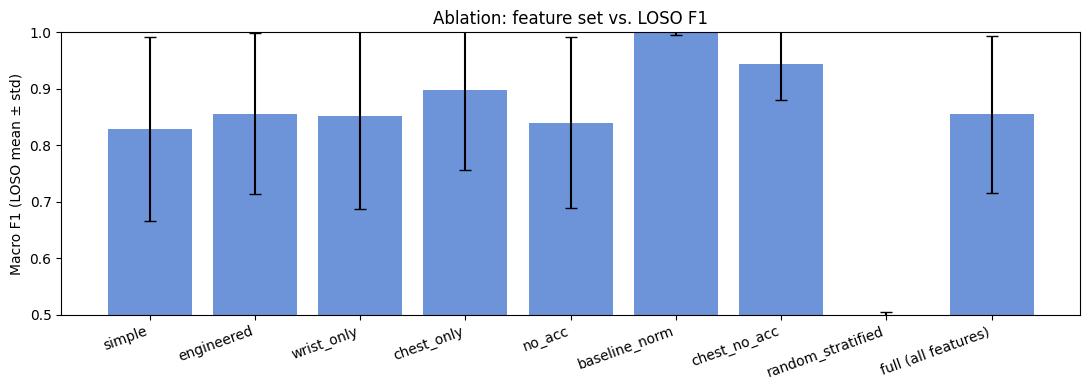

In [32]:
# ── Ablation summary ──────────────────────────────────────────────────────
summary = pd.DataFrame({
    name: {"LOSO F1 mean": df["f1"].mean(), "LOSO F1 std": df["f1"].std()}
    for name, df in abl_results.items()
}).T.round(3)

# Add full-feature baseline row if available
if "dev_df" in dir():
    summary.loc["full (all features)"] = {
        "LOSO F1 mean": dev_df["f1"].mean(),
        "LOSO F1 std":  dev_df["f1"].std()
    }
print(summary.sort_values("LOSO F1 mean", ascending=False).to_string())

# Bar chart with error bars
fig, ax = plt.subplots(figsize=(11, 4))
labels = summary.index.tolist()
means  = summary["LOSO F1 mean"].values
stds   = summary["LOSO F1 std"].values
ax.bar(labels, means, yerr=stds, capsize=4, color="#4878d0", alpha=0.8)
ax.set_ylabel("Macro F1 (LOSO mean ± std)")
ax.set_title("Ablation: feature set vs. LOSO F1")
ax.set_ylim(0.5, 1.0)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Final model — train on all dev subjects, evaluate on S2

This is the one and only time the test set is touched.

/Users/dylannguyen/Desktop/CS 372/finalproject/wesad/.venv/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


── Test results (S2 ──────────────────────
Macro F1 : 0.970
Accuracy : 0.973

              precision    recall  f1-score   support

  non-stress       1.00      0.96      0.98      5732
      stress       0.92      1.00      0.96      2652

    accuracy                           0.97      8384
   macro avg       0.96      0.98      0.97      8384
weighted avg       0.98      0.97      0.97      8384

── Timing ──────────────────────────────────
Training time     : 407.6 s  (113424 windows, 57 features)
Inference time    : 3.0 ms  for 8384 windows  (avg of 10 runs)
Per-window latency: 0.36 µs/window


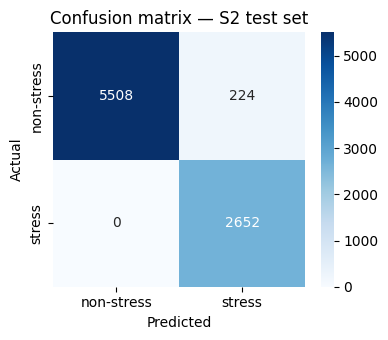

In [55]:
# Final model: chest features excluding ACC
import time

chest_no_acc = [
    f for f in FEATURE_COLS
    if f.startswith(('ecg_', 'chest_', 'emg_', 'resp_', 'cross_')) and '_ACC_' not in f
]
idx = [FEATURE_COLS.index(f) for f in chest_no_acc]
Xd_cna = X_dev[:,  idx]
Xt_cna = X_test[:, idx]

final_ebm = ExplainableBoostingClassifier(
    feature_names=chest_no_acc,
    max_bins=128,
    max_interaction_bins=32,
    interactions=0,
    learning_rate=0.01,
    min_samples_leaf=2,
    random_state=42,
)

t0_train = time.perf_counter()
final_ebm.fit(Xd_cna, y_dev)
t1_train = time.perf_counter()
train_time = t1_train - t0_train

# Inference timing: repeat 10x and average to reduce noise
N_REPS = 10
t0_inf = time.perf_counter()
for _ in range(N_REPS):
    test_preds = final_ebm.predict(Xt_cna)
t1_inf = time.perf_counter()
infer_total_ms = (t1_inf - t0_inf) / N_REPS * 1000   # ms per full test set
infer_per_win  = infer_total_ms / len(Xt_cna) * 1000  # µs per window

print(f"── Test results (S2 ──────────────────────")
print(f"Macro F1 : {f1_score(y_test, test_preds, average='macro'):.3f}")
print(f"Accuracy : {accuracy_score(y_test, test_preds):.3f}")
print()
print(classification_report(y_test, test_preds, target_names=["non-stress", "stress"]))
print(f"── Timing ──────────────────────────────────")
print(f"Training time     : {train_time:.1f} s  ({Xd_cna.shape[0]} windows, {Xd_cna.shape[1]} features)")
print(f"Inference time    : {infer_total_ms:.1f} ms  for {len(Xt_cna)} windows  (avg of {N_REPS} runs)")
print(f"Per-window latency: {infer_per_win:.2f} µs/window")

# Confusion matrix
cm  = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["non-stress", "stress"],
            yticklabels=["non-stress", "stress"], ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion matrix — S2 test set")
plt.tight_layout()
plt.show()

### Global explanations

Shape functions for every feature — how each feature's value maps to a contribution toward the stress prediction. This is the main scientific payoff of using an EBM.

In [33]:
ebm_global = final_ebm.explain_global(name="EBM — global feature importance")
show(ebm_global)

<!-- http://127.0.0.1:7076/5716428848/ -->

### Local explanations

Per-window breakdown of which features pushed the prediction toward stress or non-stress. Pick an interesting test window to show in your demo.

In [46]:
# Recompute the test slice using the model's own feature list
cna_cols = list(final_ebm.feature_names_in_)
cna_idx  = [FEATURE_COLS.index(f) for f in cna_cols]
X_test_df = pd.DataFrame(X_test[:, cna_idx], columns=cna_cols)
y_test_s  = pd.Series(y_test)

ebm_local = final_ebm.explain_local(X_test_df, y_test_s, name="EBM — local explanations (S2 test set)")
show(ebm_local)

<!-- http://127.0.0.1:7076/4423419328/ -->

In [12]:
# save model
import pickle

with open(PROCESSED_DIR / "final_ebm.pkl", "wb") as f:
    pickle.dump(final_ebm, f)

print(f"Saved → {PROCESSED_DIR / 'final_ebm.pkl'}")


Saved → ../data/WESAD/processed_basic/final_ebm.pkl
